# GRU


## 简介
Gated Recurrent Unit (GRU) 引入门控机制改进 RNN。

不是每个观察值都同等重要，只想记住关键信息
- 能关注重点的机制（更新门）
- 能遗忘的机制（重置门）

## 门
输出 $(0, 1)$ 之间的值，控制信息的流动

![gate](./images/gru-gate.svg)

$$R_t = \sigma(W_{xr}x_t + W_{hr}h_{t-1} + b_r)$$
$$Z_t = \sigma(W_{xz}x_t + W_{hz}h_{t-1} + b_z)$$

其中 $\sigma$ 是 Sigmoid 函数，输出在 $(0, 1)$ 之间。

## 候选隐藏状态
部分遗忘上一时刻的隐藏状态，结合当前时刻的输入，得到候选隐藏状态

![candidate](./images/gru-candidate.svg)

$$\tilde{H_t} = \tanh(W_{xh}x_t + W_{hh}(R_t \odot h_{t-1}) + b_h)$$

与 RNN 相比，$W_{hh}h_{t-1}$ 变成了 $W_{hh}(R_t \odot h_{t-1})$
- $\odot$ 表示逐元素相乘
- $R_t$ 中元素范围是 $(0, 1)$

所以 $R_t \odot h_{t-1}$ 可以选择性地遗忘上一时刻的隐藏状态
- $R_t$ 全 0，则 $\tilde{H_t} = \tanh(W_{xh}x_t + b_h)$，完全遗忘上一时刻的隐藏状态
- $R_t$ 全 1，则 $\tilde{H_t} = \tanh(W_{xh}x_t + W_{hh}h_{t-1} + b_h)$，完全记住，与 RNN 相同
- $R_t$ 中元素在 0 和 1 之间，则 $\tilde{H_t}$ 部分遗忘上一时刻的隐藏状态

## 隐藏状态

在旧状态和新候选状态中进行平衡。

![hidden](./images/gru-hidden.svg)

$$H_t = Z_t \odot h_{t-1} + (1 - Z_t) \odot \tilde{H_t}$$
- $Z_t$ 中元素范围是 $(0, 1)$
- $1-Z_t$ 中元素范围是 $(0, 1)$

所以 $Z_t \odot h_{t-1}$ 可以选择性地记住上一时刻的隐藏状态，$(1 - Z_t) \odot \tilde{H_t}$ 可以选择性地记住候选隐藏状态
- $Z_t$ 全 0，则 $H_t = \tilde{H_t}$，只记住候选隐藏状态
- $Z_t$ 全 1，则 $H_t = h_{t-1}$，只记住上一时刻的隐藏状态，与 RNN 相同
- $Z_t$ 中元素在 0 和 1 之间，则 $H_t$ 融合上一时刻的隐藏状态和候选隐藏状态


## 从零实现


In [7]:
import torch
from torch import nn
import util

In [8]:
batch_size = 32
num_steps = 35
train_iter, vocab = util.data.load_data_time_machine(batch_size, num_steps)

初始化参数


In [9]:
def get_params(vocab_size, num_hiddens, device):
    num_inputs = num_outputs = vocab_size # 输出层的维度和词表大小相同
    def normal(shape):
        return torch.randn(size=shape, device=device) * 0.01
    def three():
        """两个 W 和一个 b"""
        return (normal((num_inputs, num_hiddens)), # Wx
                normal((num_hiddens, num_hiddens)), # Wh
                torch.zeros(num_hiddens, device=device)) # b
    W_xz, W_hz, b_z = three()  # 更新门参数
    W_xr, W_hr, b_r = three()  # 重置门参数
    W_xh, W_hh, b_h = three()  # 候选隐藏状态参数
    # 输出层参数
    W_hq = normal((num_hiddens, num_outputs))
    b_q = torch.zeros(num_outputs, device=device)
    # 附上梯度
    params = [W_xz, W_hz, b_z, W_xr, W_hr, b_r,
              W_xh, W_hh, b_h, W_hq, b_q]
    for param in params:
        param.requires_grad_(True)
    return params

初始化隐藏状态


In [10]:
def init_gru_state(batch_size, num_hiddens, device):
    return (torch.zeros((batch_size, num_hiddens), device=device), )

定义 GRU 前向计算


In [11]:
def gru(inputs, state, params):
    # 参数
    (W_xz, W_hz, b_z,
     W_xr, W_hr, b_r,
     W_xh, W_hh, b_h,
     W_hq, b_q) = params
    # 状态
    H, = state
    outputs = []
    for X in inputs:
        # 门控
        Z = torch.sigmoid(X @ W_xz + H @ W_hz + b_z) # 更新门
        R = torch.sigmoid(X @ W_xr + H @ W_hr + b_r) # 重置门
        # 候选隐藏状态
        H_tilda = torch.tanh(X @ W_xh + (R * H) @ W_hh + b_h)
        # 隐藏状态
        H = Z * H + (1 - Z) * H_tilda
        # 输出层
        Y = H @ W_hq + b_q
        outputs.append(Y)
    return torch.cat(outputs, dim=0), (H,)

训练


困惑度 3.7, 49293.2 token/秒
预测: time traveller stood and the stars and strange and the spoke of t
预测: traveller and the strange grous of the sun stead of the sun 


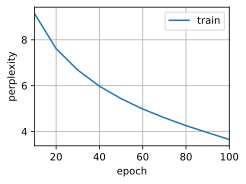

In [12]:
vocab_size = len(vocab)
num_hiddens = 256
device = util.try_gpu()
num_epochs = 100
lr = 1
model = util.model.RNNModelScratch(len(vocab), num_hiddens, device, get_params, init_gru_state, gru)
util.train.train_ch8(model, train_iter, vocab, lr, num_epochs, device)

## 简洁实现


困惑度 2.8, 631095.9 token/秒
预测: time traveller starping that i should have sat down the same stan
预测: traveller storping of the stars to rest the thing was and sh


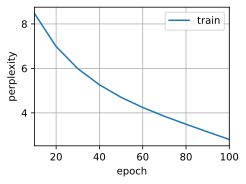

In [13]:
gru_layer = nn.GRU(input_size=vocab_size, hidden_size=num_hiddens)
model = util.model.RNNModel(gru_layer, vocab_size).to(device)
util.train.train_ch8(model, train_iter, vocab, lr, num_epochs, device)